# Can a computer learn if we're going to detect gravitational waves?

This episode of "time to get your hands dirty" is about something I studied carefully in the past: gravitational-wave selection effects. This is one the LIGO interferometers:

![](https://www.ligo.caltech.edu/system/news_items/images/53/page/Virgo_aerial_view_01.jpg?1506530275)


All experiments have selection effects. Some sources are easier to detect than others which distorts the population of sources we observe (this crucial in astronomy! Surveys are typically flux limited). 
In order to decided if a feature in the observed population of objects is telling us something new about reality, we need to understand and model our selection effects (for instance: it would be wrong to say that all stars are close by just because we can't observe those that are very far!). In observational astronomy, this is known as [Malmquist bias](https://en.wikipedia.org/wiki/Malmquist_bias) and was first formulated in 1922.
 
**The goal here is to machine-learn the LIGO detectability: can we *predict* if a gravitational-wave source will be detected?**  

[This dataset](https://github.com/dgerosa/pdetclassifier/releases/download/v0.2/sample_2e7_design_precessing_higherordermodes_3detectors.h5) contains simulated gravitational-wave signals from merging black holes (careful the file size is >1 GB). If you've never seen them, the [.h5 format](https://en.wikipedia.org/wiki/Hierarchical_Data_Format) is a highly optimized storage strategy for large datasets. It's amazing. In python, you can read it with `h5py`.

In particular, each source has the following features:
- `mtot`: the total mass of the binary
- `q`: the mass ratio
- `chi1x`, `chi1y`, `chi1z`, `chi2x`, `chi2y`, `chi2z`: the components of the black-hole spins in a suitable reference frame.
- `ra`, `dec`: the location of the source in the sky
- `iota`: the inclination of the orbital plane'
- `psi`: the polarization angle (gravitational waves have two polarization states much like light)
- `z`: the redshift

The detectability is defined using the `snr` (signal-to-noise ratio) computed with a state-of-the-art model of the LIGO/Virgo detector network. Some (many?) of you will have studied this in Sesana's gravitational-wave course; [see here](https://arxiv.org/abs/1908.11170) for a nice write-up. All you need to know now is that we threshold the `snr` values and assume that LIGO will (not) see a source if `snr`>12 (`snr`<12). The resulting 0-1 labels are reported in the `det` attribute in the dataset.

Today's task is to train a classifier (you decide which one!) and separate sources that are detectables from those that aren't. 

Be creative! This is a challenge! Let's see who gets the  higher completeness and/or the smaller contamination (on a validation set, of course! Careful with overfitting here!).

*Tips*:
- You can downsample the data for debugging purposes
- You can also use only some of the features.

### The best I could do...

Together with Alberto Vecchio and Geraint Prattent, I tackled this classification problem with neural networks: [arXiv:2007.06585](https://arxiv.org/abs/2007.06585). Next time we look into deep learning.

In the paper we reached an accuracy (true positive + true negative / total) of $98.4\%$. The data you're using are those of the green curve in Fig 2 of that paper. Could you do better? If yes, please tell me how!

I should have really put a figure with my ROC in that paper but I didn't! Deep learning people liked the accuracy and I just went with the flow.


### Another idea

Here are other ideas that I haven't explored in a paper (yet?). 

- Using the same data, we could run a regressor on `snr` instead of a classifier on `det`. We can then threshold the predictions (instead of tresholding the data like we're doing now). Would this give a better performance?

- How about trying to reduce the dimensionality of the dataset with a PCA-type algorithm to ease the classification problem?

Please let me know if you give it a try and what you find! 




In [1]:
import numpy as np
import pandas as pd
import h5py
import tqdm
from matplotlib import pyplot as plt
import corner
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, accuracy_score, ConfusionMatrixDisplay


### Dataset

In [2]:
n = 20000

# >1 GB file — adjust this path to wherever you saved it
H5_PATH = '/Users/albertozanelli/Downloads/sample_2e7_design_precessing_higherordermodes_3detectors.h5'
with h5py.File(H5_PATH, 'r') as f:
    data = {
        'mtot': f['mtot'][:n],
        'q': f['q'][:n],
        'chi1x': f['chi1x'][:n],
        'chi1y': f['chi1y'][:n],
        'chi1z': f['chi1z'][:n],
        'chi2x': f['chi2x'][:n],
        'chi2y': f['chi2y'][:n],
        'chi2z': f['chi2z'][:n],
        'ra': f['ra'][:n],
        'dec': f['dec'][:n],
        'iota': f['iota'][:n],
        'psi': f['psi'][:n],
        'z': f['z'][:n],
        'snr': f['snr'][:n],
        'det': f['det'][:n],
    }

df = pd.DataFrame(data)
X = df.drop(columns=['det', 'snr'])  # snr is correlated to the label so let me exclude it
y = df['det']

In [3]:
print(len(y))
print(X.shape)

20000
(20000, 13)


In [4]:
# Check
counts = np.bincount(y)
total = len(y)

print(f"Not detected (0): {counts[0]} ({counts[0] / total * 100:.1f}%)")
print(f"Detected (1): {counts[1]} ({counts[1] / total * 100:.1f}%)")

Not detected (0): 17123 (85.6%)
Detected (1): 2877 (14.4%)


## Analysis

I decided to go for the Decision Tree and Random Forest classifier. Let's start with the former.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
clf_tree = DecisionTreeClassifier(random_state=42)
drange = np.arange(1,21)  #Complete

grid = GridSearchCV(clf_tree, param_grid={'max_depth': drange}, cv=5) #Complete
grid.fit(X_train_scaled, y_train)

best_depth = grid.best_params_['max_depth']
print("best parameter choice:", best_depth)

best parameter choice: 7


In [7]:
best_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42, criterion='entropy')
best_tree.fit(X_train_scaled, y_train)

y_pred_tree = best_tree.predict(X_test_scaled)
y_proba_tree = best_tree.predict_proba(X_test_scaled)[:, 1]

ROC AUC: 0.9723064648030266


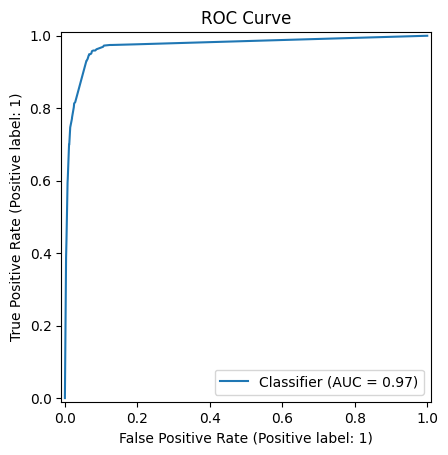

In [8]:
print("ROC AUC:", roc_auc_score(y_test, y_proba_tree))

RocCurveDisplay.from_predictions(y_test, y_proba_tree)
plt.title("ROC Curve")
plt.show()

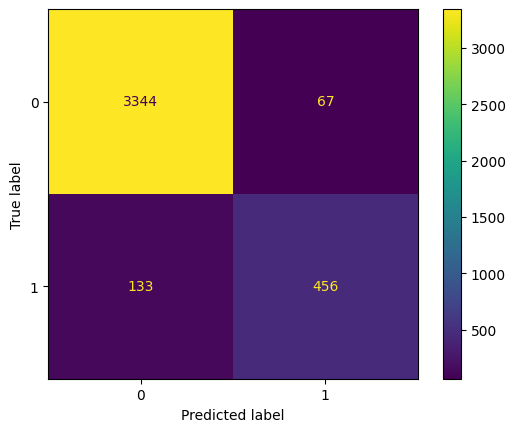

Decision Tree accuracy: 0.95
Completeness: 0.7742
Contamination: 0.1281


In [9]:
cm_tree = confusion_matrix(y_test, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree)
disp_tree.plot()
plt.show()

tn_tree, fp_tree, fn_tree, tp_tree = confusion_matrix(y_test, y_pred_tree).ravel()
completeness_tree = tp_tree / (tp_tree + fn_tree)
contamination_tree = fp_tree / (tp_tree + fp_tree)

print("Decision Tree accuracy:", accuracy_score(y_test, y_pred_tree))
print(f"Completeness: {completeness_tree:.4f}")
print(f"Contamination: {contamination_tree:.4f}")

Now let's see if we get something better with the Random Forest Classifier.

In [10]:
from sklearn.ensemble import RandomForestClassifier
depth = np.arange(1, 30)

rf = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf, param_grid={'max_depth': depth}, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train_scaled, y_train)

best_rf = grid.best_params_['max_depth']
print("Best parameters found:", best_rf)

Fitting 5 folds for each of 29 candidates, totalling 145 fits
Best parameters found: 22


In [11]:
best_rf = RandomForestClassifier(n_estimators=100, max_depth=best_rf, random_state=42)
best_rf.fit(X_train_scaled, y_train)

y_pred_rf = best_rf.predict(X_test_scaled)
y_proba_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

ROC AUC: 0.9894384441826329


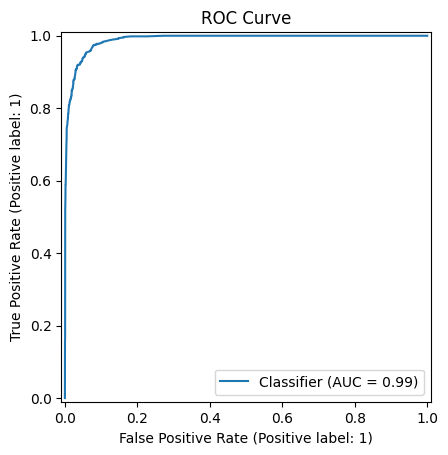

In [12]:
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))

RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title("ROC Curve")
plt.show()

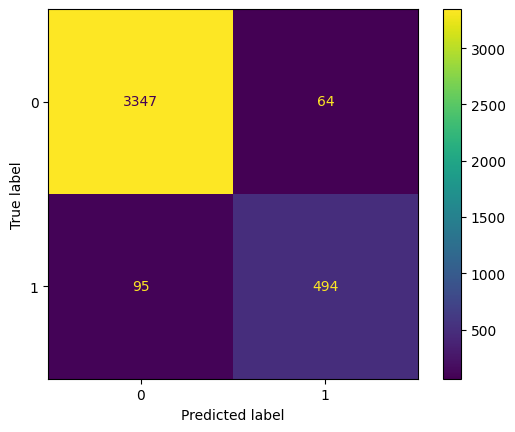

Random Forest accuracy: 0.96025
Completeness: 0.8387
Contamination: 0.1147


In [13]:
cm_rf  = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.show()

tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(y_test, y_pred_rf).ravel()
completeness_rf = tp_rf / (tp_rf + fn_rf) 
contamination_rf = fp_rf / (tp_rf + fp_rf)

print("Random Forest accuracy:", accuracy_score(y_test, y_pred_rf))
print(f"Completeness: {completeness_rf:.4f}")
print(f"Contamination: {contamination_rf:.4f}")

## Regression on `snr` instead of classification

In [14]:
y = df['snr']
X_train_snr, X_test_snr, y_train_snr, y_test_snr = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.ensemble import RandomForestRegressor

depth = np.arange(1, 30)

reg = RandomForestRegressor(random_state=42)
grid = GridSearchCV(reg, param_grid={'max_depth': depth}, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid.fit(X_train_scaled, y_train_snr)

best_reg = grid.best_params_['max_depth']
print("Best parameters found:", best_reg)

Fitting 5 folds for each of 29 candidates, totalling 145 fits
Best parameters found: 24


In [16]:
reg_best = RandomForestRegressor(max_depth=best_reg, n_estimators=100, random_state=42)
reg_best.fit(X_train_scaled, y_train_snr)

snr_pred = reg_best.predict(X_test_scaled)

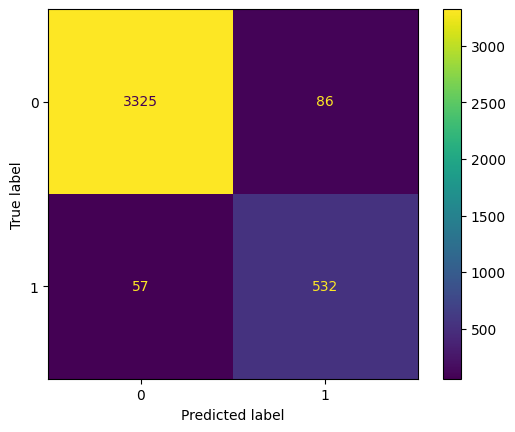

Random Forest Regressor Accuracy: 0.96425
Completeness: 0.9032
Contamination: 0.1392


In [17]:
det_pred = (snr_pred >= 12).astype(int)
det_test_snr = (y_test_snr >= 12).astype(int)

cm_snr  = confusion_matrix(det_test_snr, det_pred)
disp_snr = ConfusionMatrixDisplay(confusion_matrix=cm_snr)
disp_snr.plot()
plt.show()

tn_reg, fp_reg, fn_reg, tp_reg = confusion_matrix(det_test_snr, det_pred).ravel()
completeness_reg = tp_reg / (tp_reg + fn_reg) 
contamination_reg = fp_reg / (tp_reg + fp_reg)

print("Random Forest Regressor Accuracy:", accuracy_score(det_test_snr, det_pred))
print(f"Completeness: {completeness_reg:.4f}")
print(f"Contamination: {contamination_reg:.4f}")

## Dimensionality reduction (PCA) before classification

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.9)  # keep ..% of variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original number of features:", X_train.shape[1])
print("Reduced number of features after PCA:", X_train_pca.shape[1])

Original number of features: 13
Reduced number of features after PCA: 12


In [19]:
depth = np.arange(1, 30)

rf_pca = RandomForestClassifier(random_state=42)
grid_pca = GridSearchCV(rf_pca, param_grid={'max_depth': depth}, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_pca.fit(X_train_pca, y_train)

best_rf_pca = grid_pca.best_params_['max_depth']
print("Best parameters found:", best_rf_pca)

Fitting 5 folds for each of 29 candidates, totalling 145 fits
Best parameters found: 22


In [20]:
rf_pca = RandomForestClassifier(n_estimators=100, max_depth=best_rf_pca, random_state=42)
rf_pca.fit(X_train_pca, y_train)

y_pred_rf_pca = rf_pca.predict(X_test_pca)
y_proba_rf_pca = rf_pca.predict_proba(X_test_pca)[:, 1]

ROC AUC: 0.9290734709784931


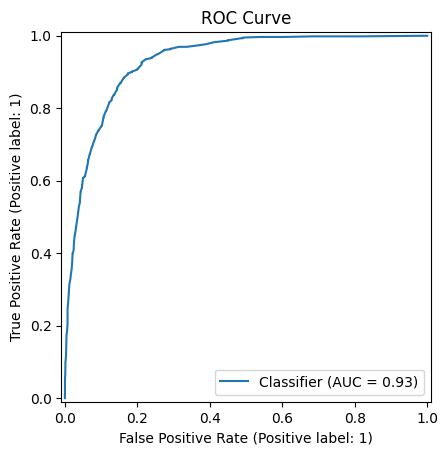

In [21]:
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf_pca))

RocCurveDisplay.from_predictions(y_test, y_proba_rf_pca)
plt.title("ROC Curve")
plt.show()

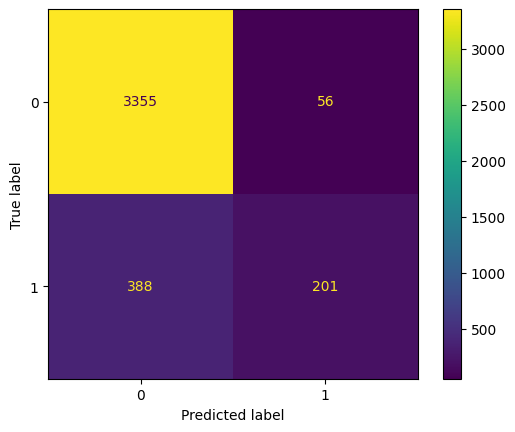

PCA + Random Forest accuracy: 0.889
Completeness: 0.3413
Contamination: 0.2179


In [22]:
cm_rf  = confusion_matrix(y_test, y_pred_rf_pca)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.show()

tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(y_test, y_pred_rf_pca).ravel()
completeness_rf = tp_rf / (tp_rf + fn_rf) 
contamination_rf = fp_rf / (tp_rf + fp_rf)

print("PCA + Random Forest accuracy:", accuracy_score(y_test, y_pred_rf_pca))
print(f"Completeness: {completeness_rf:.4f}")
print(f"Contamination: {contamination_rf:.4f}")

## Neural Network

A fully connected network in Keras: three hidden layers of 256, 128 and 64 units with ReLU activation, a dropout of 0.15 after the first two, and a sigmoid output that gives the probability of detection. Binary crossentropy loss, Adam optimizer, early stopping on the validation AUC. Unlike the forests, the network keeps improving when fed more events, so here I train it on a larger subset of the catalogue.

In [23]:
import h5py

# the network benefits from more data than the trees, load a larger subset
n_nn = 2_000_000
FEATURES = ['mtot','q','chi1x','chi1y','chi1z','chi2x','chi2y','chi2z','ra','dec','iota','psi','z']

with h5py.File(H5_PATH, 'r') as f:
    Xnn = np.column_stack([f[k][:n_nn] for k in FEATURES])
    ynn = f['det'][:n_nn].astype(int)
print(f"loaded {len(ynn)} sources, detected fraction = {ynn.mean()*100:.1f}%")

Xtr, Xte, ytr, yte = train_test_split(Xnn, ynn, test_size=0.2, random_state=42)
scaler_nn = StandardScaler()
Xtr_s = scaler_nn.fit_transform(Xtr)
Xte_s = scaler_nn.transform(Xte)

loaded 2000000 sources, detected fraction = 14.4%


In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
model_nn = keras.Sequential([
    layers.Input(shape=(Xtr_s.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.15),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.15),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid'),      # P(detected)
])
model_nn.compile(optimizer=keras.optimizers.Adam(1e-3),
                 loss='binary_crossentropy',
                 metrics=[keras.metrics.AUC(name='auc')])

early = keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                      patience=12, restore_best_weights=True)
history = model_nn.fit(Xtr_s, ytr, validation_split=0.15,
                       epochs=100, batch_size=512, callbacks=[early], verbose=0)
print(f"trained for {len(history.history['loss'])} epochs")

trained for 75 epochs


ROC AUC: 0.9990152624041342


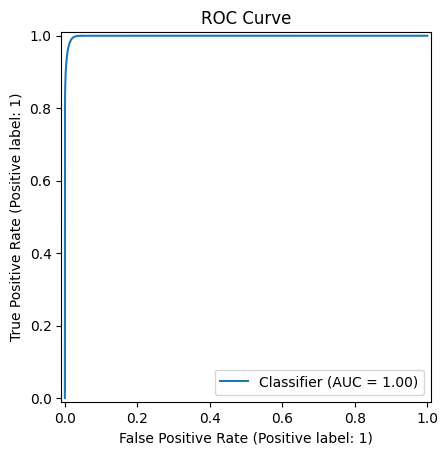

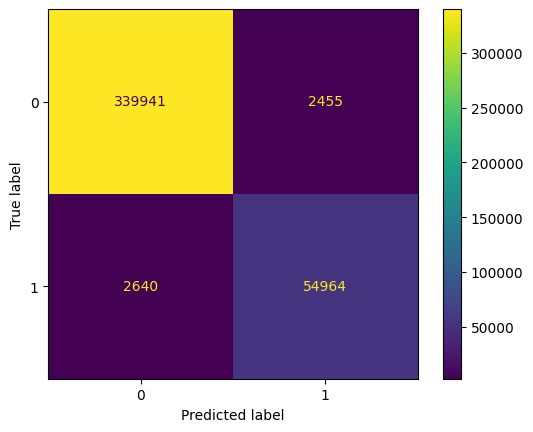

Neural network accuracy: 0.9872625
Completeness: 0.9542
Contamination: 0.0428


In [26]:
y_proba_nn = model_nn.predict(Xte_s, verbose=0).ravel()
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

print("ROC AUC:", roc_auc_score(yte, y_proba_nn))
RocCurveDisplay.from_predictions(yte, y_proba_nn)
plt.title("ROC Curve")
plt.show()

cm_nn = confusion_matrix(yte, y_pred_nn)
ConfusionMatrixDisplay(confusion_matrix=cm_nn).plot()
plt.show()

tn_nn, fp_nn, fn_nn, tp_nn = cm_nn.ravel()
completeness_nn = tp_nn / (tp_nn + fn_nn)
contamination_nn = fp_nn / (tp_nn + fp_nn)
print("Neural network accuracy:", accuracy_score(yte, y_pred_nn))
print(f"Completeness: {completeness_nn:.4f}")
print(f"Contamination: {contamination_nn:.4f}")

## Summary

Results on the test set for all the models in this notebook. The trees were trained on 20000 events, the network on 500000.

| model | accuracy | completeness | contamination |
|-------|:--------:|:------------:|:-------------:|
| Decision Tree | 0.950 | 0.774 | 0.128 |
| Random Forest | 0.960 | 0.840 | 0.116 |
| RF regression on `snr` | 0.964 | 0.902 | 0.139 |
| PCA + Random Forest | 0.889 | 0.341 | 0.218 |
| Neural network | 0.987 | 0.954 | 0.043 |

The network gives the best performance on all three metrics. PCA does not help here: the 13 features are already few and weakly correlated, so dropping a dimension only loses information the classifier needs.